In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
df1 = pd.read_csv("../data/file1.csv")
df1.head()

,id,deleted,deleted_by_cascade,created_at,updated_at,price,volume,total_volume,amount,rnn,status,is_send,temperature,pressure,branch_id,dispenser_id,shift_id,operator_id,filial_created_at,filial_updated_at,video_record_id,arm_price,density,car_id,district_id,fuel_type_violation,pressure_violation,region_id,technically_inspection,without_violations,tenant_id
0,56058,NaN,False,2025-05-13 04:41:59.700977+00:00,2025-05-13 04:43:29.981374+00:00,5200.0,11.477,38747.987,59680.4,0,not_fiscally,False,35.5,209.0,1,3,41,1,2025-05-13 04:39:21.846000+00:00,2025-05-13 04:40:42.747565+00:00,NaN,0.0,NaN,NaN,234,0,1,1,0,0,1
1,55876,NaN,False,2025-05-13 04:02:59.944583+00:00,2025-05-13 04:03:59.156251+00:00,5200.0,14.820,108079.817,77064.0,0,not_fiscally,False,23.0,198.0,1,5,41,1,2025-05-13 02:56:10.617000+00:00,2025-05-13 02:59:58.605636+00:00,NaN,0.0,NaN,NaN,234,0,0,1,0,1,1
2,56130,NaN,False,2025-05-13 05:26:59.376711+00:00,2025-05-13 05:27:59.491744+00:00,5200.0,9.618,108521.336,50010.0,0,not_fiscally,False,29.0,166.0,1,5,41,1,2025-05-13 05:24:00.863000+00:00,2025-05-13 05:25:18.252443+00:00,NaN,0.0,NaN,NaN,234,0,0,1,0,1,1
3,57260,NaN,False,2025-05-14 02:10:30.340607+00:00,2025-05-14 02:11:25.975696+00:00,5200.0,9.617,110574.041,50008.4,0,not_fiscally,False,16.5,188.0,1,5,42,1,2025-05-13 23:03:02.367000+00:00,2025-05-13 23:06:16.439069+00:00,NaN,0.0,NaN,NaN,234,0,0,1,0,1,1
4,56509,NaN,False,2025-05-13 09:59:00.115763+00:00,2025-05-13 10:00:31.128977+00:00,5200.0,12.825,51518.273,66690.0,0,not_fiscally,False,35.5,210.0,1,11,41,1,2025-05-13 09:55:56.649000+00:00,2025-05-13 09:57:47.920788+00:00,39290.0,0.0,NaN,1860.0,234,0,1,1,0,0,1


In [5]:
df1.tail()

,id,deleted,deleted_by_cascade,created_at,updated_at,price,volume,total_volume,amount,rnn,status,is_send,temperature,pressure,branch_id,dispenser_id,shift_id,operator_id,filial_created_at,filial_updated_at,video_record_id,arm_price,density,car_id,district_id,fuel_type_violation,pressure_violation,region_id,technically_inspection,without_violations,tenant_id
204821,198523,NaN,False,2025-09-08 00:26:51.003794+00:00,2025-09-08 00:26:51.665024+00:00,5200.0,9.616,516201.101,50000.0,0,not_fiscally,False,25.5,229.0,1,7,160,1,2025-09-08 00:22:38.003000+00:00,2025-09-08 00:23:23.499715+00:00,154618.0,0.0,1.0,31332.0,234,0,1,1,0,0,1
204822,199110,NaN,False,2025-09-08 07:47:51.162410+00:00,2025-09-08 07:47:53.188949+00:00,5200.0,9.384,345396.570,48796.8,0,not_fiscally,False,31.0,207.0,1,9,160,1,2025-09-08 07:43:49.235000+00:00,2025-09-08 07:44:16.220364+00:00,155203.0,0.0,1.0,5963.0,234,0,1,1,0,0,1
204823,199414,NaN,False,2025-09-08 11:39:51.535612+00:00,2025-09-08 11:40:52.552245+00:00,5200.0,14.727,392956.749,76580.4,0,not_fiscally,False,32.5,207.0,1,8,160,1,2025-09-08 11:35:46.108000+00:00,2025-09-08 11:36:38.595484+00:00,155514.0,0.0,1.0,15531.0,234,0,1,1,0,0,1
204824,199371,NaN,False,2025-09-08 11:09:51.734859+00:00,2025-09-08 11:10:51.639039+00:00,5200.0,28.359,135943.879,147466.8,0,not_fiscally,False,31.0,207.0,1,4,160,1,2025-09-08 11:05:37.366000+00:00,2025-09-08 11:06:35.149102+00:00,155468.0,0.0,1.0,5722.0,234,0,1,1,0,0,1
204825,199053,NaN,False,2025-09-08 07:06:52.132806+00:00,2025-09-08 07:06:53.539892+00:00,5200.0,8.909,415517.238,46326.8,0,not_fiscally,False,7.5,210.0,1,5,160,1,2025-09-08 07:02:50.614000+00:00,2025-09-08 07:03:19.338345+00:00,155148.0,0.0,1.0,4526.0,234,0,1,1,0,0,1


In [6]:
df1.shape

(204826, 31)

In [7]:
df1['filial_created_at'].nunique()


204826

In [8]:
df1['filial_updated_at'].nunique()

204743

In [9]:
df1[['created_at', 'filial_created_at', 'filial_updated_at']].head(10)

,created_at,filial_created_at,filial_updated_at
0,2025-05-13 04:41:59.700977+00:00,2025-05-13 04:39:21.846000+00:00,2025-05-13 04:40:42.747565+00:00
1,2025-05-13 04:02:59.944583+00:00,2025-05-13 02:56:10.617000+00:00,2025-05-13 02:59:58.605636+00:00
2,2025-05-13 05:26:59.376711+00:00,2025-05-13 05:24:00.863000+00:00,2025-05-13 05:25:18.252443+00:00
3,2025-05-14 02:10:30.340607+00:00,2025-05-13 23:03:02.367000+00:00,2025-05-13 23:06:16.439069+00:00
4,2025-05-13 09:59:00.115763+00:00,2025-05-13 09:55:56.649000+00:00,2025-05-13 09:57:47.920788+00:00
5,2025-05-13 12:00:00.696513+00:00,2025-05-13 11:57:09.977000+00:00,2025-05-13 11:57:51.175505+00:00
6,2025-05-13 04:14:31.560354+00:00,2025-05-13 03:55:37.852000+00:00,2025-05-13 03:57:42.744366+00:00
7,2025-05-13 08:52:30.235063+00:00,2025-05-13 08:49:52.587000+00:00,2025-05-13 08:50:28.386959+00:00
8,2025-05-13 09:10:29.991038+00:00,2025-05-13 09:07:26.314000+00:00,2025-05-13 09:07:43.494952+00:00
9,2025-05-13 10:10:30.183519+00:00,2025-05-13 10:07:31.927000+00:00,2025-05-13 10:09:19.474695+00:00


In [10]:
df1.isnull().sum()

id                             0
deleted                   204826
deleted_by_cascade             0
created_at                     0
updated_at                     0
price                          0
volume                         0
total_volume                   0
amount                         0
rnn                            0
status                         0
is_send                        0
temperature                    0
pressure                       0
branch_id                      0
dispenser_id                   0
shift_id                       0
operator_id                    0
filial_created_at              0
filial_updated_at              0
video_record_id           121457
arm_price                      0
density                    61236
car_id                    121457
district_id                    0
fuel_type_violation            0
pressure_violation             0
region_id                      0
technically_inspection         0
without_violations             0
tenant_id 

In [11]:
df1.describe()

,id,deleted,price,volume,total_volume,amount,rnn,temperature,pressure,branch_id,dispenser_id,shift_id,operator_id,video_record_id,arm_price,density,car_id,district_id,fuel_type_violation,pressure_violation,region_id,technically_inspection,without_violations,tenant_id
count,204826.000000,0.0,204826.000000,204826.000000,204826.000000,2.048260e+05,204826.0,204826.000000,204826.000000,204826.0,204826.000000,204826.000000,204826.000000,83369.000000,204826.0,143590.000000,83369.000000,204826.0,204826.000000,204826.000000,204826.0,204826.000000,204826.000000,204826.0
mean,102594.393226,NaN,4995.070450,13.973148,188850.167747,6.964757e+04,0.0,28.284156,203.685168,1.0,7.337345,83.794323,1.001587,94983.828425,0.0,0.319810,13834.820725,234.0,0.014920,0.434974,1.0,0.043979,0.539058,1.0
std,59144.936038,NaN,428.284111,8.827380,137139.741258,4.387441e+04,0.0,9.714140,18.088816,0.0,2.381059,48.208117,0.039802,54486.470429,0.0,0.777843,12750.328124,0.0,0.121233,0.495755,0.0,0.205048,0.498473,0.0
min,1.000000,NaN,4100.000000,0.000000,0.000000,0.000000e+00,0.0,-39.500000,0.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.0,-2.000000,1.000000,234.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0
25%,51372.250000,NaN,5200.000000,9.672000,66769.615000,5.000000e+04,0.0,25.500000,198.000000,1.0,6.000000,37.000000,1.000000,33447.000000,0.0,0.000000,3114.000000,234.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0
50%,102753.500000,NaN,5200.000000,12.535000,172657.241000,6.246760e+04,0.0,30.000000,204.000000,1.0,7.000000,86.000000,1.000000,118344.000000,0.0,0.000000,8872.000000,234.0,0.000000,0.000000,1.0,0.000000,1.000000,1.0
75%,153974.750000,NaN,5200.000000,16.267000,299658.006000,8.077550e+04,0.0,34.000000,212.000000,1.0,9.000000,125.000000,1.000000,139375.000000,0.0,1.000000,24013.000000,234.0,0.000000,1.000000,1.0,0.000000,1.000000,1.0
max,204864.000000,NaN,5200.000000,291.133000,532203.960000,1.300005e+06,0.0,45.500000,252.000000,1.0,14.000000,164.000000,2.000000,160793.000000,0.0,1.000000,41679.000000,234.0,1.000000,1.000000,1.0,1.000000,1.000000,1.0


In [12]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204826 entries, 0 to 204825
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      204826 non-null  int64  
 1   deleted                 0 non-null       float64
 2   deleted_by_cascade      204826 non-null  bool   
 3   created_at              204826 non-null  object 
 4   updated_at              204826 non-null  object 
 5   price                   204826 non-null  float64
 6   volume                  204826 non-null  float64
 7   total_volume            204826 non-null  float64
 8   amount                  204826 non-null  float64
 9   rnn                     204826 non-null  int64  
 10  status                  204826 non-null  object 
 11  is_send                 204826 non-null  bool   
 12  temperature             204826 non-null  float64
 13  pressure                204826 non-null  float64
 14  branch_id           

In [13]:
df1.nunique()

id                        204501
deleted                        0
deleted_by_cascade             1
created_at                204826
updated_at                204826
price                          2
volume                     25750
total_volume              202387
amount                     38442
rnn                            1
status                         1
is_send                        1
temperature                   99
pressure                     448
branch_id                      1
dispenser_id                  14
shift_id                     162
operator_id                    2
filial_created_at         204826
filial_updated_at         204743
video_record_id            83072
arm_price                      1
density                        4
car_id                     28689
district_id                    1
fuel_type_violation            2
pressure_violation             2
region_id                      1
technically_inspection         2
without_violations             2
tenant_id 

In [14]:
new_df1 = df1[["id", "created_at", "filial_created_at", "price", "volume",
               "amount", "dispenser_id", "operator_id",
               "car_id", "temperature", "density", "branch_id",
               "shift_id", "arm_price"]].copy()

In [15]:
new_df1.head()

,id,created_at,filial_created_at,price,volume,amount,dispenser_id,operator_id,car_id,temperature,density,branch_id,shift_id,arm_price
0,56058,2025-05-13 04:41:59.700977+00:00,2025-05-13 04:39:21.846000+00:00,5200.0,11.477,59680.4,3,1,NaN,35.5,NaN,1,41,0.0
1,55876,2025-05-13 04:02:59.944583+00:00,2025-05-13 02:56:10.617000+00:00,5200.0,14.820,77064.0,5,1,NaN,23.0,NaN,1,41,0.0
2,56130,2025-05-13 05:26:59.376711+00:00,2025-05-13 05:24:00.863000+00:00,5200.0,9.618,50010.0,5,1,NaN,29.0,NaN,1,41,0.0
3,57260,2025-05-14 02:10:30.340607+00:00,2025-05-13 23:03:02.367000+00:00,5200.0,9.617,50008.4,5,1,NaN,16.5,NaN,1,42,0.0
4,56509,2025-05-13 09:59:00.115763+00:00,2025-05-13 09:55:56.649000+00:00,5200.0,12.825,66690.0,11,1,1860.0,35.5,NaN,1,41,0.0


In [16]:
new_df1.shape

(204826, 14)

In [17]:
new_df1.isnull().sum()

id                        0
created_at                0
filial_created_at         0
price                     0
volume                    0
amount                    0
dispenser_id              0
operator_id               0
car_id               121457
temperature               0
density               61236
branch_id                 0
shift_id                  0
arm_price                 0
dtype: int64

In [18]:
new_df1.duplicated().sum()

np.int64(0)

In [19]:
new_df1.nunique()

id                   204501
created_at           204826
filial_created_at    204826
price                     2
volume                25750
amount                38442
dispenser_id             14
operator_id               2
car_id                28689
temperature              99
density                   4
branch_id                 1
shift_id                162
arm_price                 1
dtype: int64

In [20]:
new_df1["filial_created_at"] = pd.to_datetime(new_df1["filial_created_at"], format='mixed')

In [21]:
new_df1["created_at"] = pd.to_datetime(new_df1["created_at"], format='mixed')

In [22]:
new_df1["filial_created_at"].dtype

datetime64[ns, UTC]

In [23]:
new_df1["created_at"].dtype

datetime64[ns, UTC]

In [24]:
farq_soat = (new_df1['created_at'] - new_df1['filial_created_at']).dt.total_seconds() / 3600
print(farq_soat.describe())
print(farq_soat.round().value_counts().head(20))

count    204826.000000
mean         27.587706
std          78.448217
min           0.000137
25%           0.030728
50%           0.069163
75%           8.327104
max         452.314521
dtype: float64
0.0     135286
1.0       4343
2.0       3179
3.0       2228
7.0       2040
6.0       1907
8.0       1698
4.0       1604
5.0       1535
9.0       1297
20.0      1127
13.0      1109
19.0      1094
27.0      1058
23.0       995
10.0       993
17.0       981
28.0       909
21.0       894
24.0       891
Name: count, dtype: int64


In [25]:
new_df1['local_time'] = new_df1['filial_created_at'] + pd.Timedelta(hours=5)

In [26]:
new_df1['local_time'].dt.floor('s').value_counts().sort_values(ascending=False).head(20)

local_time
2025-08-15 16:58:09+00:00    5
2025-08-28 20:46:08+00:00    4
2025-08-28 22:39:17+00:00    4
2025-06-13 10:46:48+00:00    4
2025-08-26 07:19:18+00:00    3
2025-04-14 18:13:44+00:00    3
2025-06-14 14:53:33+00:00    3
2025-04-10 07:25:44+00:00    3
2025-08-14 12:57:42+00:00    3
2025-07-25 15:30:41+00:00    3
2025-08-19 08:27:30+00:00    3
2025-06-09 10:43:34+00:00    3
2025-04-14 10:55:54+00:00    3
2025-06-11 18:35:32+00:00    3
2025-04-20 08:31:43+00:00    3
2025-07-23 18:34:35+00:00    3
2025-07-13 23:14:07+00:00    3
2025-08-29 09:30:17+00:00    3
2025-07-25 12:11:14+00:00    3
2025-06-13 09:35:05+00:00    3
Name: count, dtype: int64

In [27]:
new_df1["hour"] = new_df1["local_time"].dt.hour

In [28]:
new_df1[['local_time', 'hour']].head()

,local_time,hour
0,2025-05-13 09:39:21.846000+00:00,9
1,2025-05-13 07:56:10.617000+00:00,7
2,2025-05-13 10:24:00.863000+00:00,10
3,2025-05-14 04:03:02.367000+00:00,4
4,2025-05-13 14:55:56.649000+00:00,14


In [29]:
new_df1["day_of_week"] = new_df1["local_time"].dt.day_name()

In [30]:
new_df1[['local_time', 'hour', 'day_of_week']].head()

,local_time,hour,day_of_week
0,2025-05-13 09:39:21.846000+00:00,9,Tuesday
1,2025-05-13 07:56:10.617000+00:00,7,Tuesday
2,2025-05-13 10:24:00.863000+00:00,10,Tuesday
3,2025-05-14 04:03:02.367000+00:00,4,Wednesday
4,2025-05-13 14:55:56.649000+00:00,14,Tuesday


In [31]:
new_df1['month'] = new_df1['local_time'].dt.month_name()

In [32]:
new_df1[['local_time', 'hour', 'day_of_week', 'month']].head()

,local_time,hour,day_of_week,month
0,2025-05-13 09:39:21.846000+00:00,9,Tuesday,May
1,2025-05-13 07:56:10.617000+00:00,7,Tuesday,May
2,2025-05-13 10:24:00.863000+00:00,10,Tuesday,May
3,2025-05-14 04:03:02.367000+00:00,4,Wednesday,May
4,2025-05-13 14:55:56.649000+00:00,14,Tuesday,May


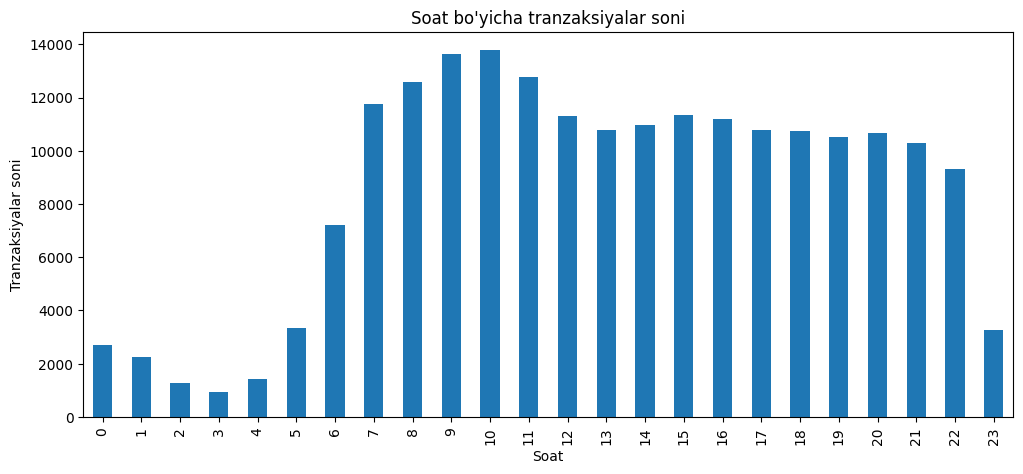

In [33]:
hourly = new_df1.groupby('hour').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)

hourly['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Soat bo\'yicha tranzaksiyalar soni')
plt.xlabel('Soat')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

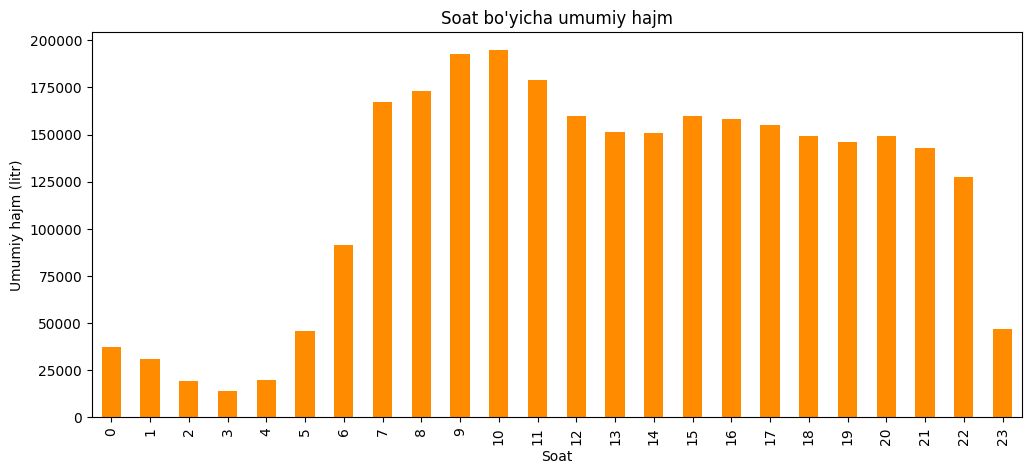

In [34]:
hourly['umumiy_hajm'].plot( kind='bar', figsize=(12,5), title='Soat bo\'yicha umumiy hajm', color='darkorange')
plt.xlabel('Soat')
plt.ylabel('Umumiy hajm (litr)')
plt.show()

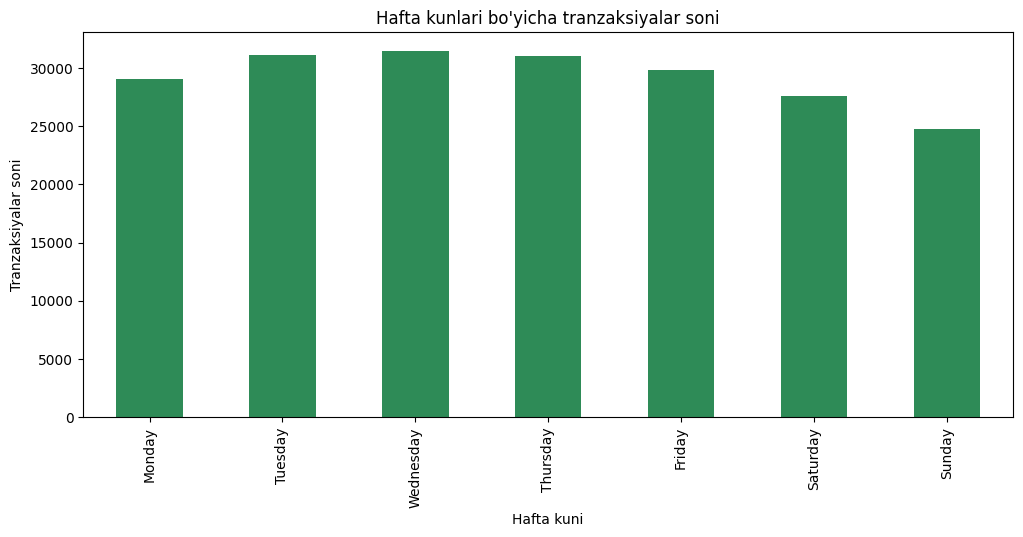

In [35]:
weekly = new_df1.groupby('day_of_week').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)

kun_tartibi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly = weekly.reindex(kun_tartibi)


weekly['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Hafta kunlari bo\'yicha tranzaksiyalar soni', color='seagreen')
plt.xlabel('Hafta kuni')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

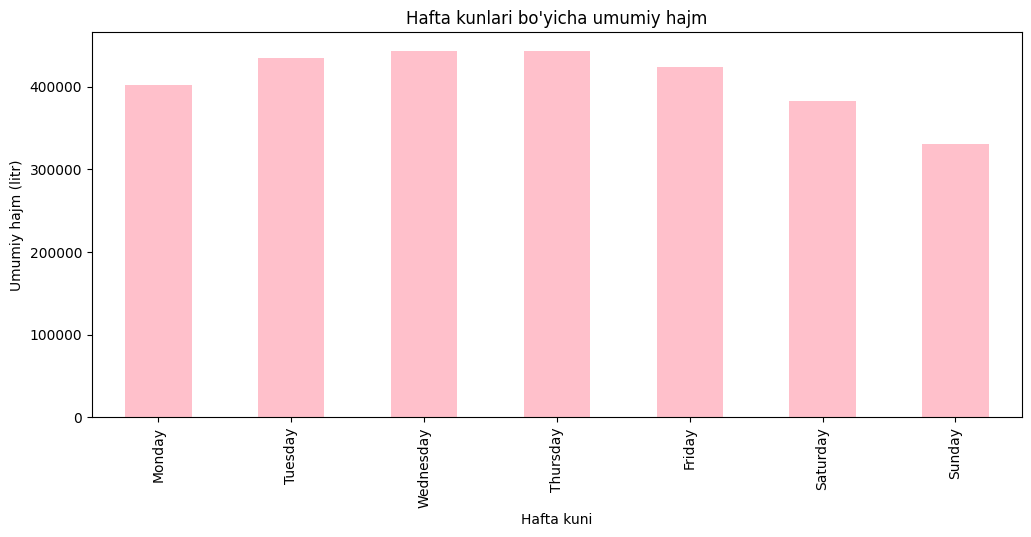

In [36]:
weekly['umumiy_hajm'].plot(kind='bar', figsize=(12,5), color='pink', title='Hafta kunlari bo\'yicha umumiy hajm')
plt.xlabel('Hafta kuni')
plt.ylabel('Umumiy hajm (litr)')
plt.show()

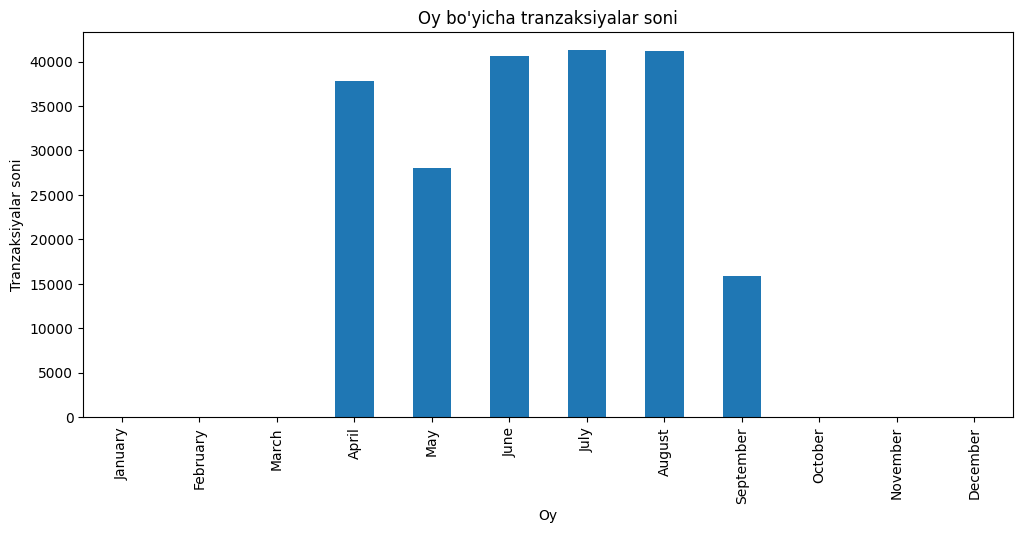

In [37]:
monthly = new_df1.groupby('month').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)
oy_tartibi = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']
monthly = monthly.reindex(oy_tartibi)

monthly['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Oy bo\'yicha tranzaksiyalar soni')
plt.xlabel('Oy')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

In [38]:
monthly

,tranzaksiyalar_soni,umumiy_hajm
month,,
January,NaN,NaN
February,NaN,NaN
March,NaN,NaN
April,37833.0,543076.184
May,27995.0,374968.592
June,40688.0,556076.741
July,41274.0,573204.306
August,41151.0,584266.623
September,15885.0,230471.599


In [39]:
new_df1.groupby('month')['local_time'].apply(lambda x: x.dt.date.nunique())

month
April        27
August       31
July         31
June         30
May          31
September    12
Name: local_time, dtype: int64

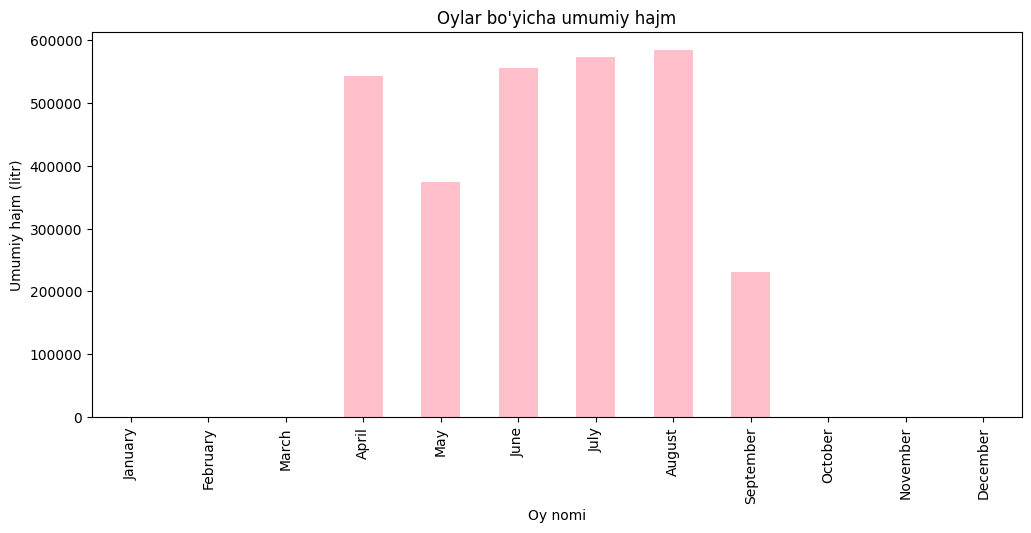

In [40]:
monthly['umumiy_hajm'].plot(kind='bar', figsize=(12,5), color='pink', title='Oylar bo\'yicha umumiy hajm')
plt.xlabel('Oy nomi')
plt.ylabel('Umumiy hajm (litr)')
plt.show()

## Xulosa: Band/bo'sh vaqtlar tahlili

**Soat bo'yicha:**

Eng band vaqt: ertalab soat 07:00-09:00 oralig'i (peak hour 08:00da, 13547 tranzaksiya)

Eng bo'sh vaqt: kechasi 00:00-04:00 oralig'i (eng kam soat 00:00da, 2895 tranzaksiya)

**Hafta kuni bo'yicha:**

Eng band kun: Seshanba (~49000 tranzaksiya)

Eng bo'sh kun: Yakshanba (~19000 tranzaksiya)

**Oy bo'yicha:**

Eng kop tranzaksiyalar bolgan oy: Iyul ( 41274ta)

Eng kam tranzaksiyalar bolgan oy: May ( 27995 ta, Aprel va Sentyabr oylari toliq berilmagani uchun May oyi tanlandi)


In [41]:
dispenser_stats = new_df1.groupby('dispenser_id').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)
dispenser_stats

,tranzaksiyalar_soni,umumiy_hajm
dispenser_id,,
1,2333,88056.286
2,2182,97451.816
3,6228,127061.104
4,6010,126103.316
5,29113,384564.500
6,30659,404628.652
7,37821,479763.745
8,27127,361072.176
9,25448,318150.825


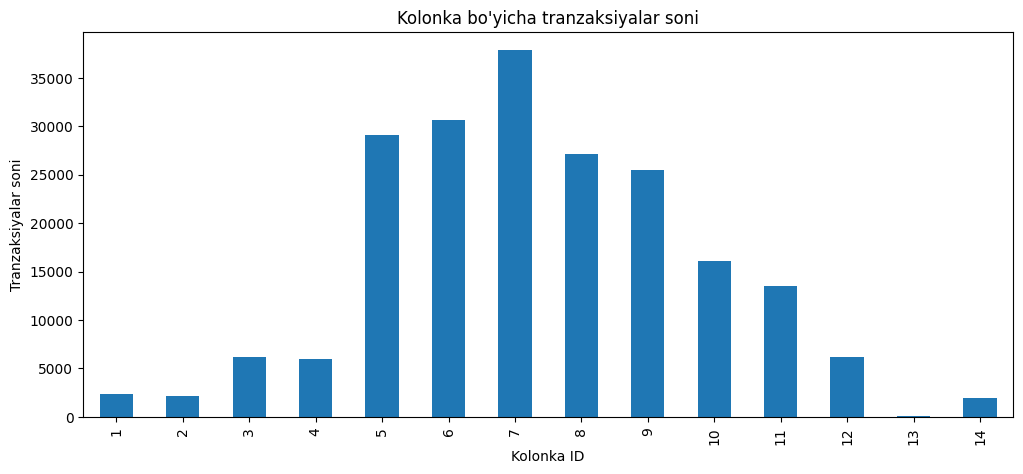

In [42]:
dispenser_stats['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Kolonka bo\'yicha tranzaksiyalar soni')
plt.xlabel('Kolonka ID')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

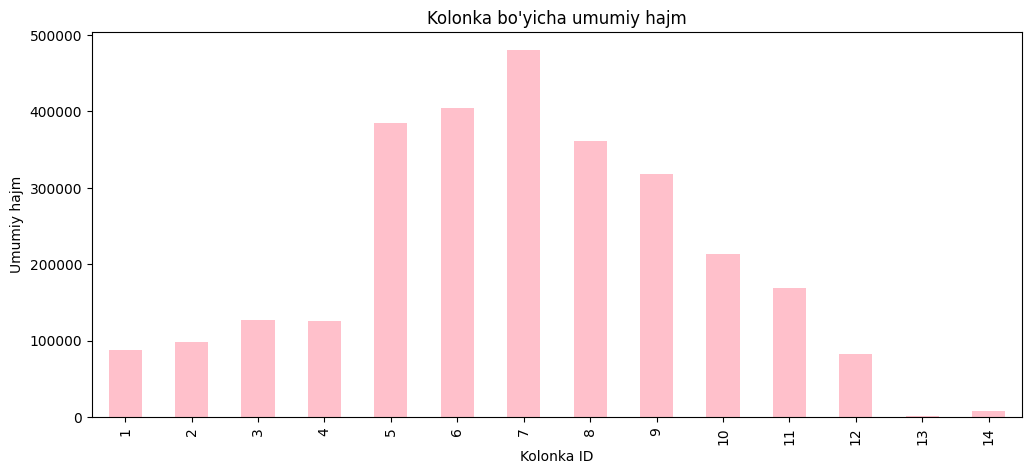

In [43]:
dispenser_stats['umumiy_hajm'].plot(kind='bar', figsize=(12,5), color='pink', title='Kolonka bo\'yicha umumiy hajm')
plt.xlabel('Kolonka ID')
plt.ylabel('Umumiy hajm')
plt.show()

In [44]:
new_df1[new_df1["dispenser_id"] == 13]["local_time"].agg(["min", "max"])

min   2025-04-09 07:37:53.402000+00:00
max   2025-09-06 11:31:53.584000+00:00
Name: local_time, dtype: datetime64[ns, UTC]

In [45]:
new_df1[new_df1["dispenser_id"] == 14]["local_time"].agg(["min", "max"])

min   2025-04-09 11:41:07.393000+00:00
max   2025-09-12 07:39:42.338000+00:00
Name: local_time, dtype: datetime64[ns, UTC]

In [46]:
new_df1[new_df1["dispenser_id"] == 7]["local_time"].agg(["min", "max"])

min   2025-04-04 06:01:34.281000+00:00
max   2025-09-12 12:04:20.416000+00:00
Name: local_time, dtype: datetime64[ns, UTC]

## Note: **dispenser_id**
Barcha 14 ta kolonka taxminan bir xil davr (5+ oy) davomida ishlagan bo'lsada, kolonka 13 va 14 boshqalariga qaraganda 100+ marta kamroq tranzaksiyaga ega (140 va 1929 ta, boshqalarida 6000-38000 ta). 
Bu farq ishlash muddati bilan bog'liq emas, shuning uchun sababi texnik nosozlik, joylashuv yoki maxsus foydalanish bo'lishi mumkin.

In [47]:
new_df1['hisoblangan_amount'] = new_df1['price'] * new_df1['volume']
farq = new_df1['amount'] - new_df1['hisoblangan_amount']
farq.describe()

count    2.048260e+05
mean    -3.459309e+01
std      5.845881e+03
min     -1.000000e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.328306e-10
dtype: float64

In [48]:
new_df1.loc[farq.idxmin()]

id                                               97061
created_at            2025-06-23 09:46:26.834368+00:00
filial_created_at     2025-06-23 09:40:19.996000+00:00
price                                           5200.0
volume                                         193.943
amount                                          8503.6
dispenser_id                                         1
operator_id                                          1
car_id                                             NaN
temperature                                       37.5
density                                            0.0
branch_id                                            1
shift_id                                            82
arm_price                                          0.0
local_time            2025-06-23 14:40:19.996000+00:00
hour                                                14
day_of_week                                     Monday
month                                             June
hisoblanga

In [49]:
new_df1[farq.abs() > 1000].shape

(7, 19)

In [50]:
print(7 / len(new_df1) * 100, "%")

0.0034175348832667725 %


In [51]:
new_df1[farq.abs() > 1000][['id', 'filial_created_at', 'price', 'volume', 'amount', 'hisoblangan_amount']]

,id,filial_created_at,price,volume,amount,hisoblangan_amount
42499,10890,2025-04-17 04:53:54.859000+00:00,4100.0,243.910,31.0,1000031.0
101273,113175,2025-07-05 12:21:20.274000+00:00,5200.0,194.843,13183.6,1013183.6
114607,97061,2025-06-23 09:40:19.996000+00:00,5200.0,193.943,8503.6,1008503.6
118885,89602,2025-06-18 00:15:15.018000+00:00,5200.0,226.555,178086.0,1178086.0
122438,105176,2025-06-29 10:29:45.262000+00:00,5200.0,192.330,116.0,1000116.0
174153,167724,2025-08-15 17:47:48.484000+00:00,5200.0,219.692,142398.4,1142398.4
178583,186225,2025-08-29 14:49:37.364000+00:00,5200.0,224.411,166937.2,1166937.2


In [52]:
new_df1[new_df1["volume"] <= 0].shape

(628, 19)

In [53]:
new_df1["volume"].shape

(204826,)

In [54]:
new_df1[new_df1["amount"] <= 0].shape

(628, 19)

In [55]:
new_df1[new_df1['volume'] <= 0]['volume'].value_counts().head(10)

volume
0.0    628
Name: count, dtype: int64

In [56]:
new_df1[new_df1['volume'] == 0]['dispenser_id'].value_counts()

dispenser_id
14    71
9     62
8     57
12    57
5     55
7     47
3     46
10    44
4     36
2     35
11    33
6     32
13    31
1     22
Name: count, dtype: int64

In [57]:
new_df1[new_df1['volume'] == 0]['dispenser_id'].value_counts()

dispenser_id
14    71
9     62
8     57
12    57
5     55
7     47
3     46
10    44
4     36
2     35
11    33
6     32
13    31
1     22
Name: count, dtype: int64

In [58]:
new_df1_clean = new_df1[(new_df1['volume'] > 0) & (farq.abs() <= 1000)].copy()

In [59]:
print("Asl qatorlar soni:", len(new_df1))
print("Tozalangandan keyin:", len(new_df1_clean))
print("Chiqarib tashlangan:", len(new_df1) - len(new_df1_clean))

Asl qatorlar soni: 204826
Tozalangandan keyin: 204191
Chiqarib tashlangan: 635


In [60]:
new_df1_clean.nlargest(10, 'volume')[['id', 'dispenser_id', 'volume', 'amount']]

,id,dispenser_id,volume,amount
30574,18702,1,291.133,1193645.3
62084,47685,1,250.001,1300005.2
72377,29858,2,225.568,924828.8
72207,29780,1,219.605,900380.0
20683,25520,2,215.972,885485.2
50108,5149,1,200.000,820000.0
43712,9097,2,195.122,800000.0
2214,58794,2,191.541,996013.2
31388,18443,4,190.811,782325.1
94387,121338,1,190.385,990000.0


In [61]:
new_df1_clean[new_df1_clean['volume'] <= 0].shape
new_df1_clean[new_df1_clean['amount'] <= 0].shape

(0, 19)

In [62]:
new_df1_clean['hisoblangan_amount_v2'] = new_df1_clean['price'] * new_df1_clean['volume']
farq_v2 = new_df1_clean['amount'] - new_df1_clean['hisoblangan_amount_v2']
farq_v2.describe()

count    2.041910e+05
mean    -4.190405e-01
std      1.117550e+00
min     -5.200000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.328306e-10
dtype: float64

In [63]:
new_df1_clean.columns.to_list()

['id',
 'created_at',
 'filial_created_at',
 'price',
 'volume',
 'amount',
 'dispenser_id',
 'operator_id',
 'car_id',
 'temperature',
 'density',
 'branch_id',
 'shift_id',
 'arm_price',
 'local_time',
 'hour',
 'day_of_week',
 'month',
 'hisoblangan_amount',
 'hisoblangan_amount_v2']

In [64]:
kerakli_ustunlar = ['local_time','hour', 'day_of_week', 'month', 'dispenser_id', 'price', 'volume', 'amount', 'branch_id']
df = new_df1_clean[kerakli_ustunlar].copy()

In [65]:
df = df.sort_values(['dispenser_id', 'local_time'])
df['xizmat_vaqti'] = df.groupby('dispenser_id')['local_time'].diff().dt.total_seconds() / 60

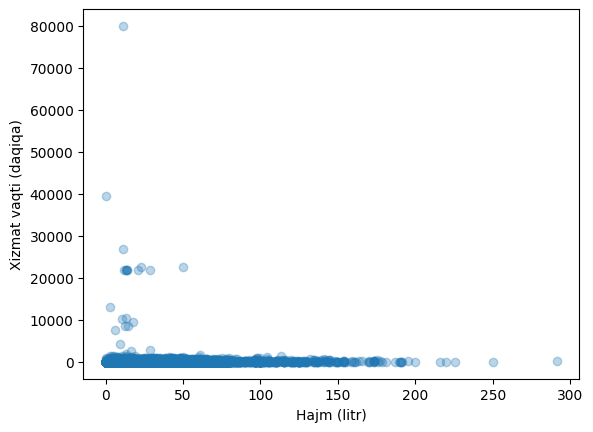

In [66]:
plt.scatter(df['volume'], df['xizmat_vaqti'], alpha=0.3)
plt.xlabel('Hajm (litr)')
plt.ylabel('Xizmat vaqti (daqiqa)')
plt.show()

In [67]:
df = df[df['xizmat_vaqti'] < 30]

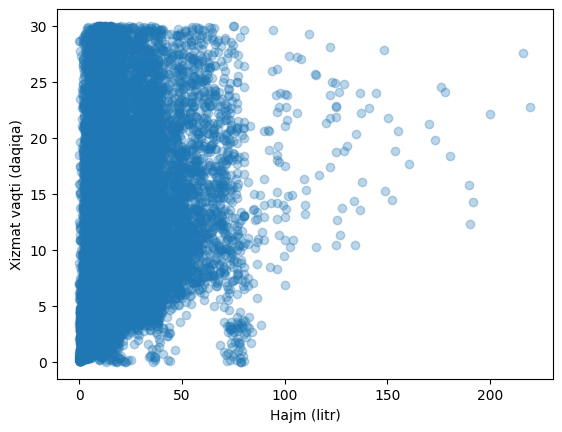

In [68]:
plt.scatter(df['volume'], df['xizmat_vaqti'], alpha=0.3)
plt.xlabel('Hajm (litr)')
plt.ylabel('Xizmat vaqti (daqiqa)')
plt.show()

In [69]:
filtered_df = df.copy()

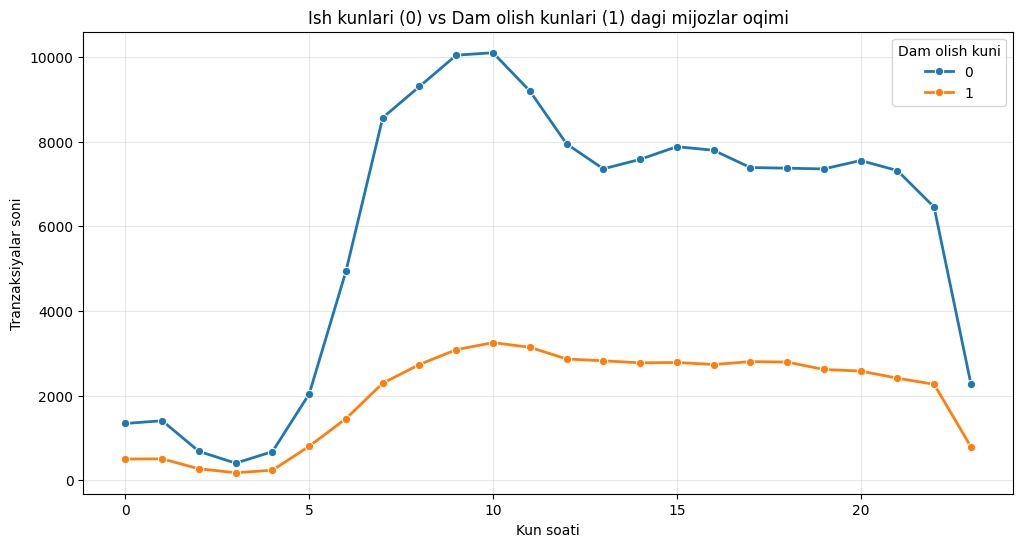

In [70]:
filtered_df['is_weekend'] = filtered_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

hourly_weekend = filtered_df.groupby(['is_weekend', 'hour'])['volume'].count().reset_index()


plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_weekend, x='hour', y='volume', hue='is_weekend', marker='o', linewidth=2)
plt.title('Ish kunlari (0) vs Dam olish kunlari (1) dagi mijozlar oqimi')
plt.xlabel('Kun soati')
plt.ylabel('Tranzaksiyalar soni')
plt.grid(True, alpha=0.3)
plt.legend(title='Dam olish kuni')
plt.show()

In [71]:
filtered_df["vaqt_intervali"] = filtered_df["local_time"].dt.floor("30min").dt.time 

In [72]:
filtered_df

,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti,is_weekend,vaqt_intervali
20817,2025-04-04 07:31:24.022000+00:00,7,Friday,April,1,4100.0,50.002,205008.2,1,5.674400,0,07:30:00
20593,2025-04-04 07:52:10.881000+00:00,7,Friday,April,1,4100.0,48.781,200000.0,1,20.780983,0,07:30:00
20888,2025-04-04 08:07:31.161000+00:00,8,Friday,April,1,4100.0,48.235,197763.5,1,15.338000,0,08:00:00
19876,2025-04-04 09:34:14.023000+00:00,9,Friday,April,1,4100.0,29.271,120010.0,1,18.807133,0,09:30:00
20392,2025-04-04 09:52:04.412000+00:00,9,Friday,April,1,4100.0,36.582,149986.2,1,17.839817,0,09:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...
198792,2025-09-10 21:26:05.944000+00:00,21,Wednesday,September,14,5200.0,3.848,20009.6,1,2.478450,0,21:00:00
199603,2025-09-11 20:38:12.762000+00:00,20,Thursday,September,14,5200.0,5.772,30010.0,1,4.123383,0,20:30:00
198903,2025-09-11 20:45:06.264000+00:00,20,Thursday,September,14,5200.0,6.154,32000.0,1,6.891700,0,20:30:00
198919,2025-09-11 20:52:27.033000+00:00,20,Thursday,September,14,5200.0,5.770,30000.0,1,7.346150,0,20:30:00


In [73]:
vaqt_intervali_stats = filtered_df.groupby(['branch_id', 'day_of_week', 'vaqt_intervali']).agg(
    faol_kolonkalar_shu_soatda=('dispenser_id', 'nunique'),  
    ortacha_hajm_shu_soatda=('volume', 'mean'), 
    jami_mashinalar_soni=('volume', 'count')
).reset_index()

vaqt_intervali_stats['ortacha_mashina_per_kolonka_shu_soatda'] = (
    vaqt_intervali_stats['jami_mashinalar_soni'] / vaqt_intervali_stats['faol_kolonkalar_shu_soatda']
)


vaqt_intervali_stats['is_weekend'] = vaqt_intervali_stats['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)


In [74]:
vaqt_intervali_stats

,branch_id,day_of_week,vaqt_intervali,faol_kolonkalar_shu_soatda,ortacha_hajm_shu_soatda,jami_mashinalar_soni,ortacha_mashina_per_kolonka_shu_soatda,is_weekend
0,1,Friday,00:00:00,8,12.683514,72,9.000000,0
1,1,Friday,00:30:00,7,13.309572,194,27.714286,0
2,1,Friday,01:00:00,8,12.749034,177,22.125000,0
3,1,Friday,01:30:00,6,14.305308,130,21.666667,0
4,1,Friday,02:00:00,5,13.167422,83,16.600000,0
...,...,...,...,...,...,...,...,...
331,1,Wednesday,21:30:00,13,13.466621,762,58.615385,0
332,1,Wednesday,22:00:00,12,13.615510,677,56.416667,0
333,1,Wednesday,22:30:00,11,13.597839,647,58.818182,0
334,1,Wednesday,23:00:00,12,14.011023,393,32.750000,0


In [75]:
vaqt_intervali_stats = vaqt_intervali_stats.sort_values(by=['branch_id', 'day_of_week', 'vaqt_intervali']).reset_index(drop=True)

vaqt_intervali_stats['mashina_soni_1_kun_oldin'] = (
    vaqt_intervali_stats.groupby(['branch_id', 'day_of_week'])['jami_mashinalar_soni'].shift(1)
)
vaqt_intervali_stats['mashina_soni_1_hafta_oldin'] = (
    vaqt_intervali_stats.groupby(['branch_id', 'day_of_week'])['jami_mashinalar_soni'].shift(7)
)


final_features = vaqt_intervali_stats[[
    'branch_id',
    'day_of_week',
    'vaqt_intervali', 
    'is_weekend',
    'faol_kolonkalar_shu_soatda', 
    'ortacha_mashina_per_kolonka_shu_soatda',
    'ortacha_hajm_shu_soatda',
]]

final_features.head(10)

,branch_id,day_of_week,vaqt_intervali,is_weekend,faol_kolonkalar_shu_soatda,ortacha_mashina_per_kolonka_shu_soatda,ortacha_hajm_shu_soatda
0,1,Friday,00:00:00,0,8,9.000000,12.683514
1,1,Friday,00:30:00,0,7,27.714286,13.309572
2,1,Friday,01:00:00,0,8,22.125000,12.749034
3,1,Friday,01:30:00,0,6,21.666667,14.305308
4,1,Friday,02:00:00,0,5,16.600000,13.167422
5,1,Friday,02:30:00,0,5,10.800000,12.726204
6,1,Friday,03:00:00,0,5,11.800000,14.642949
7,1,Friday,03:30:00,0,4,10.000000,13.716225
8,1,Friday,04:00:00,0,3,16.000000,11.803375
9,1,Friday,04:30:00,0,5,17.400000,12.292598


In [76]:
final_features.isnull().sum()

branch_id                                 0
day_of_week                               0
vaqt_intervali                            0
is_weekend                                0
faol_kolonkalar_shu_soatda                0
ortacha_mashina_per_kolonka_shu_soatda    0
ortacha_hajm_shu_soatda                   0
dtype: int64

In [77]:
final_features.count()

branch_id                                 336
day_of_week                               336
vaqt_intervali                            336
is_weekend                                336
faol_kolonkalar_shu_soatda                336
ortacha_mashina_per_kolonka_shu_soatda    336
ortacha_hajm_shu_soatda                   336
dtype: int64

In [78]:
final_features.shape

(336, 7)

In [79]:
df.shape

(191713, 10)

In [80]:
df.head()

,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti
20817,2025-04-04 07:31:24.022000+00:00,7,Friday,April,1,4100.0,50.002,205008.2,1,5.674400
20593,2025-04-04 07:52:10.881000+00:00,7,Friday,April,1,4100.0,48.781,200000.0,1,20.780983
20888,2025-04-04 08:07:31.161000+00:00,8,Friday,April,1,4100.0,48.235,197763.5,1,15.338000
19876,2025-04-04 09:34:14.023000+00:00,9,Friday,April,1,4100.0,29.271,120010.0,1,18.807133
20392,2025-04-04 09:52:04.412000+00:00,9,Friday,April,1,4100.0,36.582,149986.2,1,17.839817


In [81]:
df['volume'].value_counts()

volume
9.616     5827
9.617     2962
7.693     1978
9.618     1709
11.540    1708
          ... 
33.567       1
65.175       1
55.339       1
4.518        1
27.620       1
Name: count, Length: 23166, dtype: int64

In [82]:
kam_hajmlar = df[df['volume'] < 5]['volume'].value_counts().sort_index()
print(kam_hajmlar)

volume
0.101    1
0.102    2
0.103    1
0.104    1
0.106    1
        ..
4.995    1
4.996    2
4.997    2
4.998    2
4.999    1
Name: count, Length: 1598, dtype: int64


In [83]:
for i in [0.1, 0.5, 1, 2, 3, 5]:
    print(f"Datasetning eng pastki {i}% qismidagi chegara: {df['volume'].quantile(i/100):.3f} litr")

Datasetning eng pastki 0.1% qismidagi chegara: 0.711 litr
Datasetning eng pastki 0.5% qismidagi chegara: 2.885 litr
Datasetning eng pastki 1% qismidagi chegara: 3.849 litr
Datasetning eng pastki 2% qismidagi chegara: 4.985 litr
Datasetning eng pastki 3% qismidagi chegara: 5.770 litr
Datasetning eng pastki 5% qismidagi chegara: 6.320 litr


In [84]:
for i in [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4]:
    print(f"Datasetning eng chekka {i}% qismidagi qiymat: {df['volume'].quantile(i/100):.3f} litr")

Datasetning eng chekka 0.0% qismidagi qiymat: 0.101 litr
Datasetning eng chekka 0.01% qismidagi qiymat: 0.129 litr
Datasetning eng chekka 0.02% qismidagi qiymat: 0.164 litr
Datasetning eng chekka 0.05% qismidagi qiymat: 0.417 litr
Datasetning eng chekka 0.1% qismidagi qiymat: 0.711 litr
Datasetning eng chekka 0.2% qismidagi qiymat: 1.560 litr
Datasetning eng chekka 0.3% qismidagi qiymat: 1.926 litr
Datasetning eng chekka 0.4% qismidagi qiymat: 2.440 litr


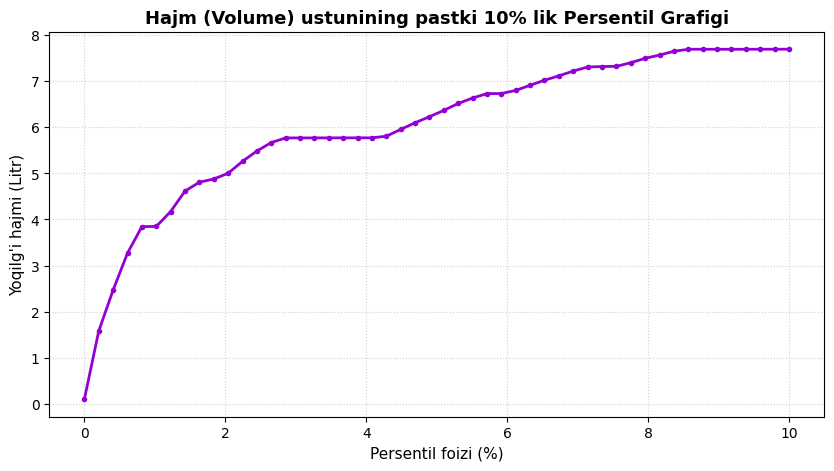

In [85]:
foizlar = np.linspace(0, 10, 50)  
qiymatlar = [df['volume'].quantile(f / 100) for f in foizlar]

plt.figure(figsize=(10, 5))
plt.plot(foizlar, qiymatlar, marker='.', color='darkviolet', linewidth=2)

plt.title("Hajm (Volume) ustunining pastki 10% lik Persentil Grafigi", fontsize=13, fontweight='bold')
plt.xlabel("Persentil foizi (%)", fontsize=11)
plt.ylabel("Yoqilg'i hajmi (Litr)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)


plt.show()

In [86]:
micro_volumes = df[df['volume'] < 2.8]

total_rows = len(df)
micro_rows = len(micro_volumes)
percent = (micro_rows / total_rows) * 100

print(f"Umumiy qatorlar soni: {total_rows}")
print(f"3 litrdan kam tranzaksiyalar soni: {micro_rows} ta")
print(percent)


micro_volumes.head(10)

Umumiy qatorlar soni: 191713
3 litrdan kam tranzaksiyalar soni: 903 ta
0.47101657164615857


,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti
20064,2025-04-04 09:54:38.733000+00:00,9,Friday,April,1,4100.0,0.644,2640.4,1,2.572017
76259,2025-04-28 06:10:04.030000+00:00,6,Monday,April,1,4100.0,2.002,8208.2,1,0.909000
60289,2025-05-06 18:42:25.950000+00:00,18,Tuesday,May,1,5200.0,0.525,2730.0,1,1.068100
60526,2025-05-06 18:44:15.645000+00:00,18,Tuesday,May,1,5200.0,0.647,3364.4,1,1.828250
60045,2025-05-06 18:44:36.820000+00:00,18,Tuesday,May,1,5200.0,0.558,2901.6,1,0.352917
59200,2025-05-06 18:45:02.290000+00:00,18,Tuesday,May,1,5200.0,0.582,3026.4,1,0.424500
59204,2025-05-06 18:46:18.350000+00:00,18,Tuesday,May,1,5200.0,1.183,6151.6,1,1.267667
59205,2025-05-06 18:47:24.417000+00:00,18,Tuesday,May,1,5200.0,0.329,1710.8,1,1.101117
15050,2025-06-09 15:08:45.893000+00:00,15,Monday,June,1,5200.0,0.102,530.4,1,5.626333
100503,2025-06-12 17:30:29.243000+00:00,17,Thursday,June,1,5200.0,0.370,1924.0,1,0.380433


In [87]:
df.drop(index=micro_volumes.index, inplace=True)

In [88]:
max_100 = df[df['volume'] > 100]
max_150 = df[df['volume'] > 150]
max_200 = df[df['volume'] > 200]
max_300 = df[df['volume'] > 300]

total_rows = len(df)

print(f"Umumiy qatorlar soni: {total_rows}\n")
print(f"100 litrdan katta tranzaksiyalar: {len(max_100)} ta ")
print(f"150 litrdan katta tranzaksiyalar: {len(max_150)} ta ")
print(f"200 litrdan katta tranzaksiyalar: {len(max_200)} ta ")
print(f"300 litrdan katta tranzaksiyalar: {len(max_300)} ta ")

df.sort_values(by='volume', ascending=False).head(10)

Umumiy qatorlar soni: 190810

100 litrdan katta tranzaksiyalar: 69 ta 
150 litrdan katta tranzaksiyalar: 16 ta 
200 litrdan katta tranzaksiyalar: 2 ta 
300 litrdan katta tranzaksiyalar: 0 ta 


,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti
72207,2025-04-25 09:57:52.505000+00:00,9,Friday,April,1,4100.0,219.605,900380.0,1,22.717950
20683,2025-04-04 07:53:42.715000+00:00,7,Friday,April,2,4100.0,215.972,885485.2,1,27.561450
50108,2025-04-22 08:08:15.799000+00:00,8,Tuesday,April,1,4100.0,200.000,820000.0,1,22.115117
2214,2025-05-14 22:24:56.047000+00:00,22,Wednesday,May,2,5200.0,191.541,996013.2,1,14.261433
94387,2025-07-11 17:36:20.628000+00:00,17,Friday,July,1,5200.0,190.385,990000.0,1,12.319467
39418,2025-06-05 16:29:07.417000+00:00,16,Thursday,June,2,5200.0,189.582,985826.4,1,15.781900
101807,2025-07-05 21:27:54.890000+00:00,21,Saturday,July,7,5200.0,180.700,939640.0,1,18.346833
32788,2025-04-11 11:26:48.891000+00:00,11,Friday,April,1,4100.0,178.243,730796.3,1,24.131383
114532,2025-06-23 13:09:19.932000+00:00,13,Monday,June,2,5200.0,175.950,914940.0,1,24.506450
106316,2025-07-09 15:28:04.304000+00:00,15,Wednesday,July,2,5200.0,173.077,900000.0,1,19.779083


In [89]:
df.drop(index=max_200.index, inplace=True)

In [90]:
df.shape

(190808, 10)

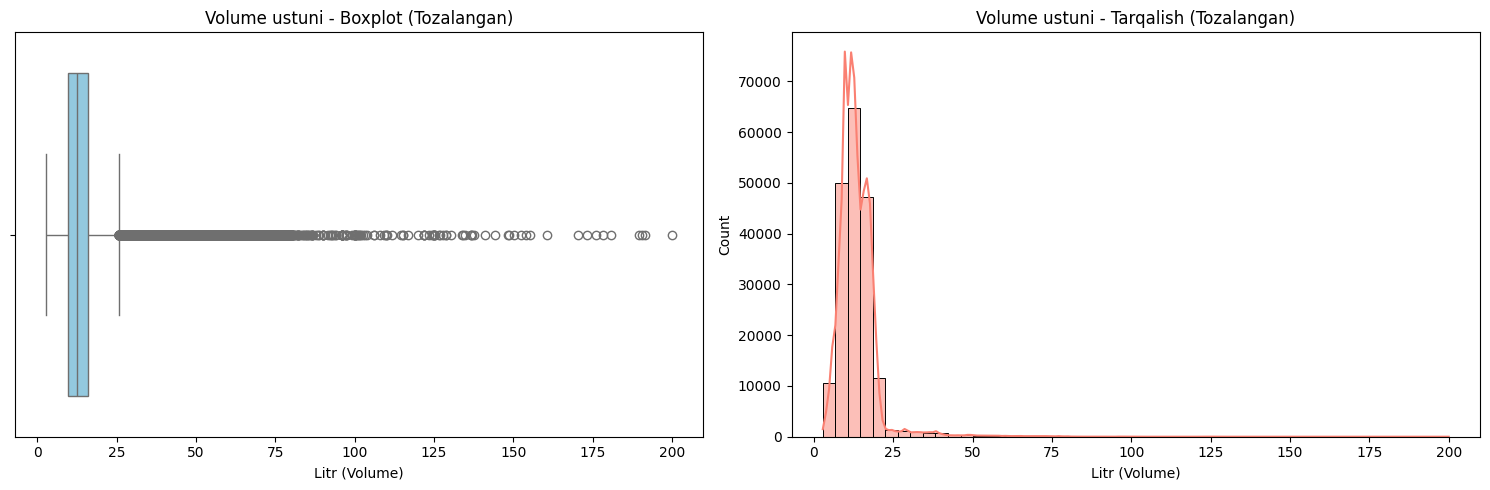

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df['volume'], ax=axes[0], color='skyblue')
axes[0].set_title("Volume ustuni - Boxplot (Tozalangan)")
axes[0].set_xlabel("Litr (Volume)")

sns.histplot(df['volume'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Volume ustuni - Tarqalish (Tozalangan)")
axes[1].set_xlabel("Litr (Volume)")

plt.tight_layout()
plt.show()

In [92]:
day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
df['day_of_week_encoded'] = df['day_of_week'].map(day_map)

In [93]:
df['date_only'] = df['local_time'].dt.date

In [94]:
hourly_data = df.groupby(['branch_id', 'date_only', 'month', 'day_of_week_encoded', 'hour']).agg(
    mashina_soni=('volume', 'count')
).reset_index()

In [95]:
branch_daily_stats = hourly_data.groupby(['branch_id', 'date_only'])['mashina_soni'].agg(['max', 'min']).reset_index()
branch_daily_stats.columns = ['branch_id', 'date_only', 'daily_max_soni', 'daily_min_soni']

hourly_data = pd.merge(hourly_data, branch_daily_stats, on=['branch_id', 'date_only'], how='left')

hourly_data['target_usul_1'] = hourly_data['mashina_soni'] / hourly_data['daily_max_soni']

hourly_data['target_usul_2'] = (hourly_data['mashina_soni'] - hourly_data['daily_min_soni']) / (hourly_data['daily_max_soni'] - hourly_data['daily_min_soni'] + 1e-5)

In [96]:
hourly_data['datetime_full'] = pd.to_datetime(hourly_data['date_only'].astype(str)) + pd.to_timedelta(hourly_data['hour'], unit='h')

malumot = hourly_data[['branch_id', 'datetime_full', 'target_usul_2']].copy()

malumot_1kun = malumot.copy()
malumot_1kun['datetime_full'] = malumot_1kun['datetime_full'] + pd.Timedelta(days=1)
malumot_1kun = malumot_1kun.rename(columns={'target_usul_2': 'bir_kun_oldin'})

hourly_data = hourly_data.merge(malumot_1kun, on=['branch_id', 'datetime_full'], how='left')

malumot_1hafta = malumot.copy()
malumot_1hafta['datetime_full'] = malumot_1hafta['datetime_full'] + pd.Timedelta(days=7)
malumot_1hafta = malumot_1hafta.rename(columns={'target_usul_2': 'bir_hafta_oldin'})

hourly_data = hourly_data.merge(malumot_1hafta, on=['branch_id', 'datetime_full'], how='left')

hourly_data['bir_kun_oldin'] = hourly_data['bir_kun_oldin'].fillna(hourly_data['target_usul_2'].mean())
hourly_data['bir_hafta_oldin'] = hourly_data['bir_hafta_oldin'].fillna(hourly_data['target_usul_2'].mean())

In [97]:
hourly_data = hourly_data.sort_values(['branch_id', 'hour', 'datetime_full']).reset_index(drop=True)

# TARGET 1 
hourly_data['oxirgi_7kun_ortacha_usul_1'] = (
    hourly_data.groupby(['branch_id', 'hour'])['target_usul_1']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)
hourly_data['oxirgi_7kun_ortacha_usul_1'] = hourly_data['oxirgi_7kun_ortacha_usul_1'].ffill().bfill()


# TARGET 2 
hourly_data['oxirgi_7kun_ortacha_usul_2'] = (
    hourly_data.groupby(['branch_id', 'hour'])['target_usul_2']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)
hourly_data['oxirgi_7kun_ortacha_usul_2'] = hourly_data['oxirgi_7kun_ortacha_usul_2'].ffill().bfill()


hourly_data = hourly_data.sort_values(['branch_id', 'datetime_full']).reset_index(drop=True)

In [98]:
dataset_solishtirish = hourly_data[[
    'branch_id', 'month', 'day_of_week_encoded', 'hour', 
    'mashina_soni', 
    'target_usul_1', 
    'target_usul_2',  
    'bir_kun_oldin', 
    'bir_hafta_oldin',
    'oxirgi_7kun_ortacha_usul_1',
    'oxirgi_7kun_ortacha_usul_2'
]]

In [99]:
dataset_solishtirish

,branch_id,month,day_of_week_encoded,hour,mashina_soni,target_usul_1,target_usul_2,bir_kun_oldin,bir_hafta_oldin,oxirgi_7kun_ortacha_usul_1,oxirgi_7kun_ortacha_usul_2
0,1,April,4,6,47,0.465347,0.100000,0.547609,0.547609,0.285161,0.229255
1,1,April,4,7,67,0.663366,0.433333,0.547609,0.547609,0.562572,0.526265
2,1,April,4,8,86,0.851485,0.750000,0.547609,0.547609,0.784464,0.766071
3,1,April,4,9,85,0.841584,0.733333,0.547609,0.547609,0.698486,0.671024
4,1,April,4,10,98,0.970297,0.950000,0.547609,0.547609,0.910299,0.901741
...,...,...,...,...,...,...,...,...,...,...,...
3596,1,September,4,8,62,0.607843,0.578947,0.581633,0.855422,0.698486,0.671024
3597,1,September,4,9,102,1.000000,1.000000,1.000000,1.000000,0.910299,0.901741
3598,1,September,4,10,95,0.931373,0.926316,0.989796,0.915663,0.927088,0.918778
3599,1,September,4,11,78,0.764706,0.747368,0.581633,0.855422,0.867933,0.859366


In [100]:
dataset = dataset_solishtirish.copy()

In [101]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
dataset['month_encoded'] = dataset['month'].map(month_map)

In [102]:
dataset

,branch_id,month,day_of_week_encoded,hour,mashina_soni,target_usul_1,target_usul_2,bir_kun_oldin,bir_hafta_oldin,oxirgi_7kun_ortacha_usul_1,oxirgi_7kun_ortacha_usul_2,month_encoded
0,1,April,4,6,47,0.465347,0.100000,0.547609,0.547609,0.285161,0.229255,4
1,1,April,4,7,67,0.663366,0.433333,0.547609,0.547609,0.562572,0.526265,4
2,1,April,4,8,86,0.851485,0.750000,0.547609,0.547609,0.784464,0.766071,4
3,1,April,4,9,85,0.841584,0.733333,0.547609,0.547609,0.698486,0.671024,4
4,1,April,4,10,98,0.970297,0.950000,0.547609,0.547609,0.910299,0.901741,4
...,...,...,...,...,...,...,...,...,...,...,...,...
3596,1,September,4,8,62,0.607843,0.578947,0.581633,0.855422,0.698486,0.671024,9
3597,1,September,4,9,102,1.000000,1.000000,1.000000,1.000000,0.910299,0.901741,9
3598,1,September,4,10,95,0.931373,0.926316,0.989796,0.915663,0.927088,0.918778,9
3599,1,September,4,11,78,0.764706,0.747368,0.581633,0.855422,0.867933,0.859366,9


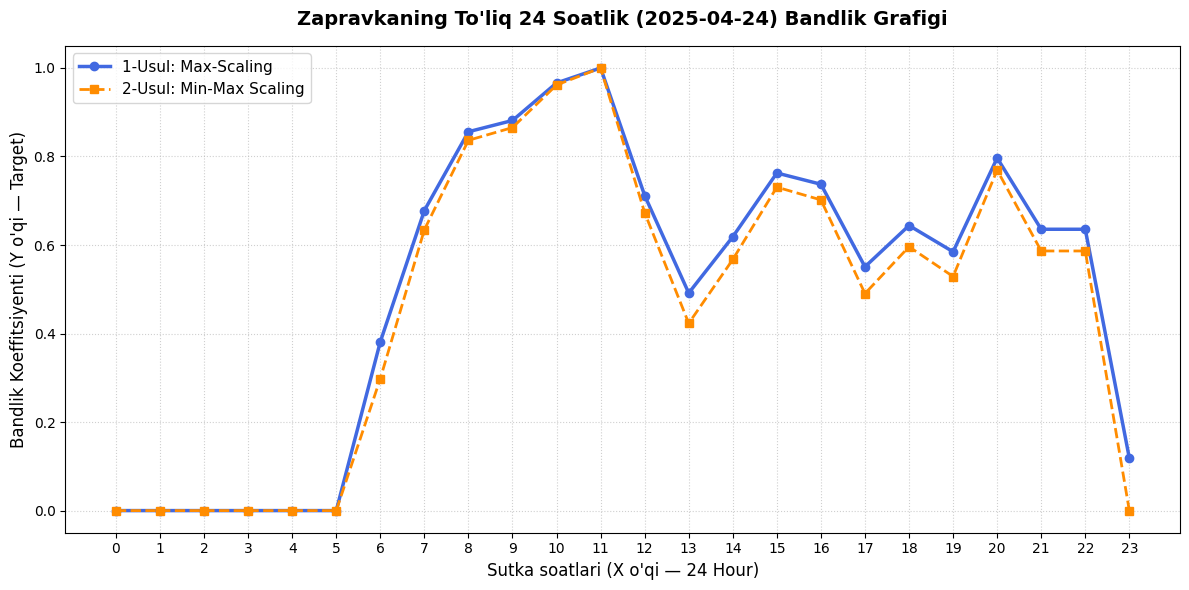

In [103]:
aniq_sana = pd.to_datetime('2025-04-24').date()


namuna_kun = dataset_solishtirish[hourly_data['date_only'] == aniq_sana].sort_values(by='hour').reset_index(drop=True)

to_liq_soatlar = pd.DataFrame({'hour': range(0, 24)})

namuna_kun = pd.merge(to_liq_soatlar, namuna_kun, on='hour', how='left')

namuna_kun['target_usul_1'] = namuna_kun['target_usul_1'].fillna(0.0)
namuna_kun['target_usul_2'] = namuna_kun['target_usul_2'].fillna(0.0)


plt.figure(figsize=(12, 6))

plt.plot(namuna_kun['hour'], namuna_kun['target_usul_1'], 
         marker='o', linestyle='-', linewidth=2.5, color='royalblue', 
         label="1-Usul: Max-Scaling")

plt.plot(namuna_kun['hour'], namuna_kun['target_usul_2'], 
         marker='s', linestyle='--', linewidth=2, color='darkorange', 
         label="2-Usul: Min-Max Scaling")

plt.title(f"Zapravkaning To'liq 24 Soatlik ({aniq_sana}) Bandlik Grafigi", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sutka soatlari (X o'qi — 24 Hour)", fontsize=12)
plt.ylabel("Bandlik Koeffitsiyenti (Y o'qi — Target)", fontsize=12)

plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

In [104]:
dataset['is_weekend'] = dataset['day_of_week_encoded'].isin([5, 6]).astype(int)

X = dataset[['branch_id', 'month_encoded', 'day_of_week_encoded', 'hour', 'is_weekend',
             'bir_kun_oldin', 'bir_hafta_oldin', 'oxirgi_7kun_ortacha_usul_1', 'oxirgi_7kun_ortacha_usul_2']]

y_1 = dataset['target_usul_1']
y_2 = dataset['target_usul_2']

In [105]:
barcha_sanalar = sorted(hourly_data['date_only'].unique())
kesim_indeks = int(len(barcha_sanalar) * 0.8) 
kesim_sana = barcha_sanalar[kesim_indeks]
print("Kesim sanasi:", kesim_sana)

Kesim sanasi: 2025-08-11


In [106]:
kesim_sana = pd.to_datetime('2025-08-11').date()
train_mask = hourly_data['date_only'] < kesim_sana
test_mask = hourly_data['date_only'] >= kesim_sana

X_train, X_test = X[train_mask], X[test_mask]

y1_train, y1_test = y_1[train_mask], y_1[test_mask]
y2_train, y2_test = y_2[train_mask], y_2[test_mask]

In [107]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2822, 9)
X_test: (779, 9)


In [165]:
learning_rates = [0.01, 0.03, 0.05, 0.1]
iterations_list = [1000, 2000, 3000]

best_mae = float('inf')
best_params = {}
results_log = []

for lr in learning_rates:
    for it in iterations_list:
        print(f"Sinab ko'rilmoqda: learning_rate={lr}, iterations={it}...")
        
        model = CatBoostRegressor(
            iterations=it,
            learning_rate=lr,
            depth=6, 
            random_seed=42,
            verbose=0 
        )
        

        model.fit(X_train, y1_train)
        
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y1_test, preds)
        
        results_log.append({'learning_rate': lr, 'iterations': it, 'MAE': mae})
        
        if mae < best_mae:
            best_mae = mae
            best_params = {'learning_rate': lr, 'iterations': it}

results_df = pd.DataFrame(results_log)
print("Eng yaxshi parametrlar:", best_params)
print("Eng past MAE xatolik:", round(best_mae, 5))

Sinab ko'rilmoqda: learning_rate=0.01, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.01, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.01, iterations=3000...
Sinab ko'rilmoqda: learning_rate=0.03, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.03, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.03, iterations=3000...
Sinab ko'rilmoqda: learning_rate=0.05, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.05, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.05, iterations=3000...
Sinab ko'rilmoqda: learning_rate=0.1, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.1, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.1, iterations=3000...
Eng yaxshi parametrlar: {'learning_rate': 0.01, 'iterations': 1000}
Eng past MAE xatolik: 0.08605


In [164]:
learning_rates = [0.01, 0.03, 0.05, 0.1]
iterations_list = [1000, 2000, 3000]

best_mae = float('inf')
best_params = {}
results_log = []

for lr in learning_rates:
    for it in iterations_list:
        print(f"Sinab ko'rilmoqda: learning_rate={lr}, iterations={it}...")
        
        model = CatBoostRegressor(
            iterations=it,
            learning_rate=lr,
            depth=6, 
            random_seed=42,
            verbose=0 
        )
        

        model.fit(X_train, y2_train)
        
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y2_test, preds)
        
        results_log.append({'learning_rate': lr, 'iterations': it, 'MAE': mae})
        
        if mae < best_mae:
            best_mae = mae
            best_params = {'learning_rate': lr, 'iterations': it}

results_df = pd.DataFrame(results_log)
print("Eng yaxshi parametrlar:", best_params)
print("Eng past MAE xatolik:", round(best_mae, 5))

Sinab ko'rilmoqda: learning_rate=0.01, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.01, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.01, iterations=3000...
Sinab ko'rilmoqda: learning_rate=0.03, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.03, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.03, iterations=3000...
Sinab ko'rilmoqda: learning_rate=0.05, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.05, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.05, iterations=3000...
Sinab ko'rilmoqda: learning_rate=0.1, iterations=1000...
Sinab ko'rilmoqda: learning_rate=0.1, iterations=2000...
Sinab ko'rilmoqda: learning_rate=0.1, iterations=3000...
Eng yaxshi parametrlar: {'learning_rate': 0.01, 'iterations': 1000}
Eng past MAE xatolik: 0.08853


In [160]:
cat_features = ['branch_id', 'day_of_week_encoded', 'is_weekend']

# Target 1
cat_model_1 = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.01, random_seed=42, verbose=False)
cat_model_1.fit(X_train, y1_train, cat_features=cat_features)

rf_model_1 = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42)
rf_model_1.fit(X_train, y1_train)

xgb_model_1 = XGBRegressor(n_estimators=80, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model_1.fit(X_train, y1_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [161]:
# Target 2
cat_model_2 = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.01, random_seed=42, verbose=False)
cat_model_2.fit(X_train, y2_train, cat_features=cat_features)

rf_model_2 = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42)
rf_model_2.fit(X_train, y2_train)

xgb_model_2 = XGBRegressor(n_estimators=98, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model_2.fit(X_train, y2_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [154]:
cat_preds_1 = cat_model_1.predict(X_test)
rf_preds_1 = rf_model_1.predict(X_test)
xgb_preds_1 = xgb_model_1.predict(X_test)

natijalar_1 = {}
for name, preds in [('CatBoost', cat_preds_1), ('RandomForest', rf_preds_1), ('XGBoost', xgb_preds_1)]:
    mae = mean_absolute_error(y1_test, preds)
    rmse = np.sqrt(mean_squared_error(y1_test, preds))
    r2 = r2_score(y1_test, preds)
    natijalar_1[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

natijalar_1_df = pd.DataFrame(natijalar_1).T
natijalar_1_df

,MAE,RMSE,R2
CatBoost,0.099867,0.129595,0.800849
RandomForest,0.082698,0.107097,0.863993
XGBoost,0.085013,0.110375,0.855540


In [155]:
cat_preds_2 = cat_model_2.predict(X_test)
rf_preds_2 = rf_model_2.predict(X_test)
xgb_preds_2 = xgb_model_2.predict(X_test)

natijalar_2 = {}
for name, preds in [('CatBoost', cat_preds_2), ('RandomForest', rf_preds_2), ('XGBoost', xgb_preds_2)]:
    mae = mean_absolute_error(y2_test, preds)
    rmse = np.sqrt(mean_squared_error(y2_test, preds))
    r2 = r2_score(y2_test, preds)
    natijalar_2[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

natijalar_2_df = pd.DataFrame(natijalar_2).T
natijalar_2_df

,MAE,RMSE,R2
CatBoost,0.100715,0.133403,0.812728
RandomForest,0.086218,0.112501,0.866815
XGBoost,0.088313,0.116701,0.856686


In [156]:
# Target 1
for name, model in [('CatBoost', cat_model_1), ('RandomForest', rf_model_1), ('XGBoost', xgb_model_1)]:
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_r1 = r2_score(y1_train, train_preds)
    test_r1 = r2_score(y1_test, test_preds)
    print(f"{name}: Train R²={train_r1:.4f}, Test R²={test_r1:.4f}, Farq={train_r1-test_r1:.4f}")

CatBoost: Train R²=0.9113, Test R²=0.8008, Farq=0.1104
RandomForest: Train R²=0.8380, Test R²=0.8640, Farq=-0.0260
XGBoost: Train R²=0.8308, Test R²=0.8555, Farq=-0.0247


In [157]:
# Target 2
for name, model in [('CatBoost', cat_model_2), ('RandomForest', rf_model_2), ('XGBoost', xgb_model_2)]:
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_r2 = r2_score(y2_train, train_preds)
    test_r2 = r2_score(y2_test, test_preds)
    print(f"{name}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}, Farq={train_r2-test_r2:.4f}")

CatBoost: Train R²=0.9045, Test R²=0.8127, Farq=0.0917
RandomForest: Train R²=0.8256, Test R²=0.8668, Farq=-0.0413
XGBoost: Train R²=0.8250, Test R²=0.8567, Farq=-0.0317


In [158]:
# Oxirgi 7 kunlik o'rtacha

baseline_preds_1 = dataset.loc[X_test.index, 'oxirgi_7kun_ortacha_usul_1']

b1_mae = mean_absolute_error(y1_test, baseline_preds_1)
b1_rmse = np.sqrt(mean_squared_error(y1_test, baseline_preds_1))
b1_r2 = r2_score(y1_test, baseline_preds_1)

baseline_preds_2 = dataset.loc[X_test.index, 'oxirgi_7kun_ortacha_usul_2']

b2_mae = mean_absolute_error(y2_test, baseline_preds_2)
b2_rmse = np.sqrt(mean_squared_error(y2_test, baseline_preds_2))
b2_r2 = r2_score(y2_test, baseline_preds_2)

print("-*-*- TARGET 1 BASELINE (7 kunlik o'rtacha) -*-*-")
print("MAE  :", round(b1_mae, 4))
print("RMSE :", round(b1_rmse, 4))
print("R2   :", round(b1_r2, 4))

print("\n-*-*- TARGET 2 BASELINE (7 kunlik o'rtacha) -*-*-")
print("MAE  :", round(b2_mae, 4))
print("RMSE :", round(b2_rmse, 4))
print("R2   :", round(b2_r2, 4))

-*-*- TARGET 1 BASELINE (7 kunlik o'rtacha) -*-*-
MAE  : 0.085
RMSE : 0.1118
R2   : 0.8518

-*-*- TARGET 2 BASELINE (7 kunlik o'rtacha) -*-*-
MAE  : 0.0889
RMSE : 0.1183
R2   : 0.8528


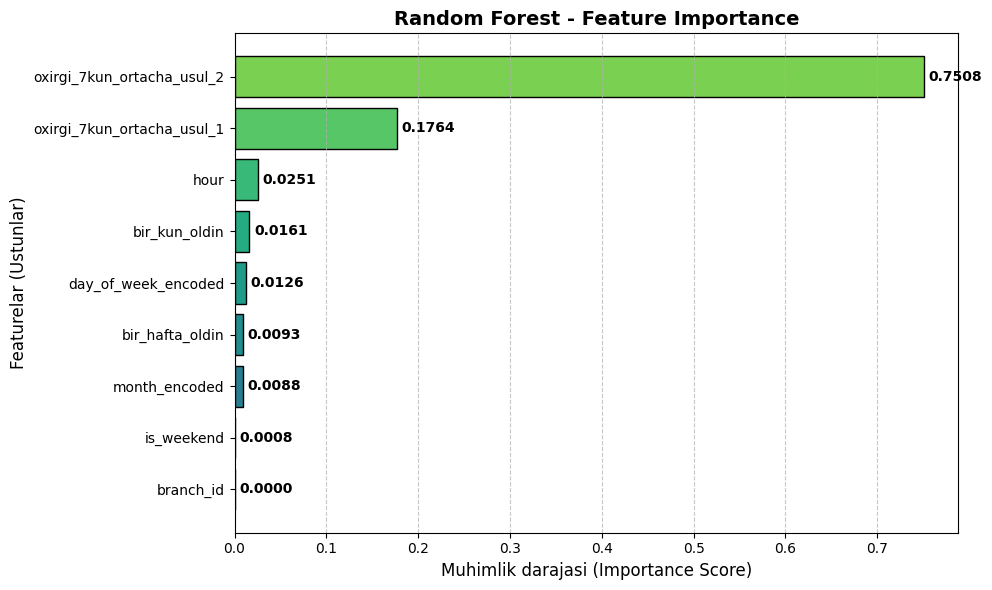

In [169]:
importances = rf_model_2.feature_importances_

feature_names = X_train.columns
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) 

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(feature_imp_df)))

plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color=colors, edgecolor='black')
plt.xlabel('Muhimlik darajasi (Importance Score)', fontsize=12)
plt.ylabel('Featurelar (Ustunlar)', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(feature_imp_df['Importance']):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

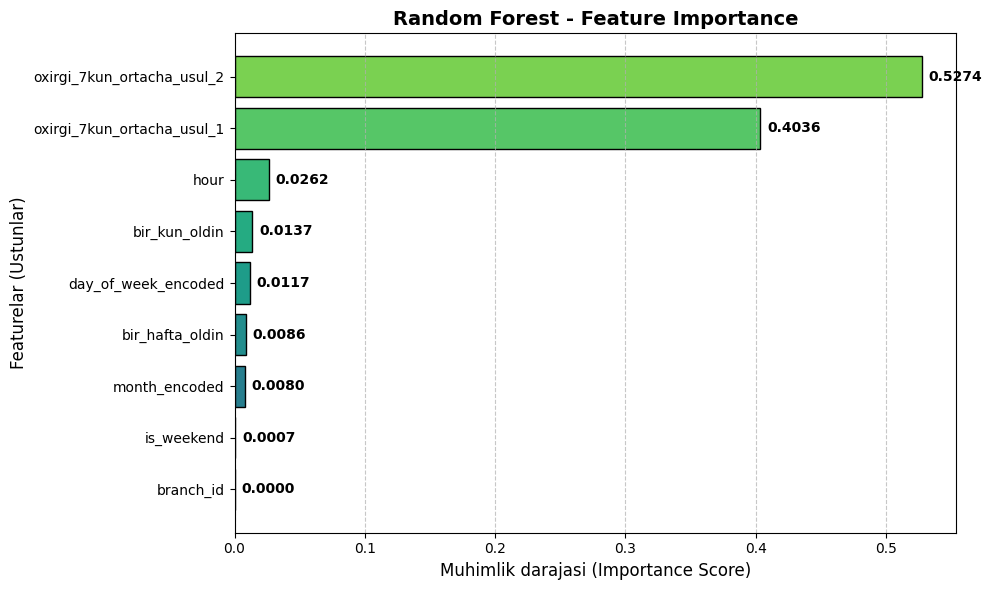

In [170]:
importances = rf_model_1.feature_importances_

feature_names = X_train.columns
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) 

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(feature_imp_df)))

plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color=colors, edgecolor='black')
plt.xlabel('Muhimlik darajasi (Importance Score)', fontsize=12)
plt.ylabel('Featurelar (Ustunlar)', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(feature_imp_df['Importance']):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

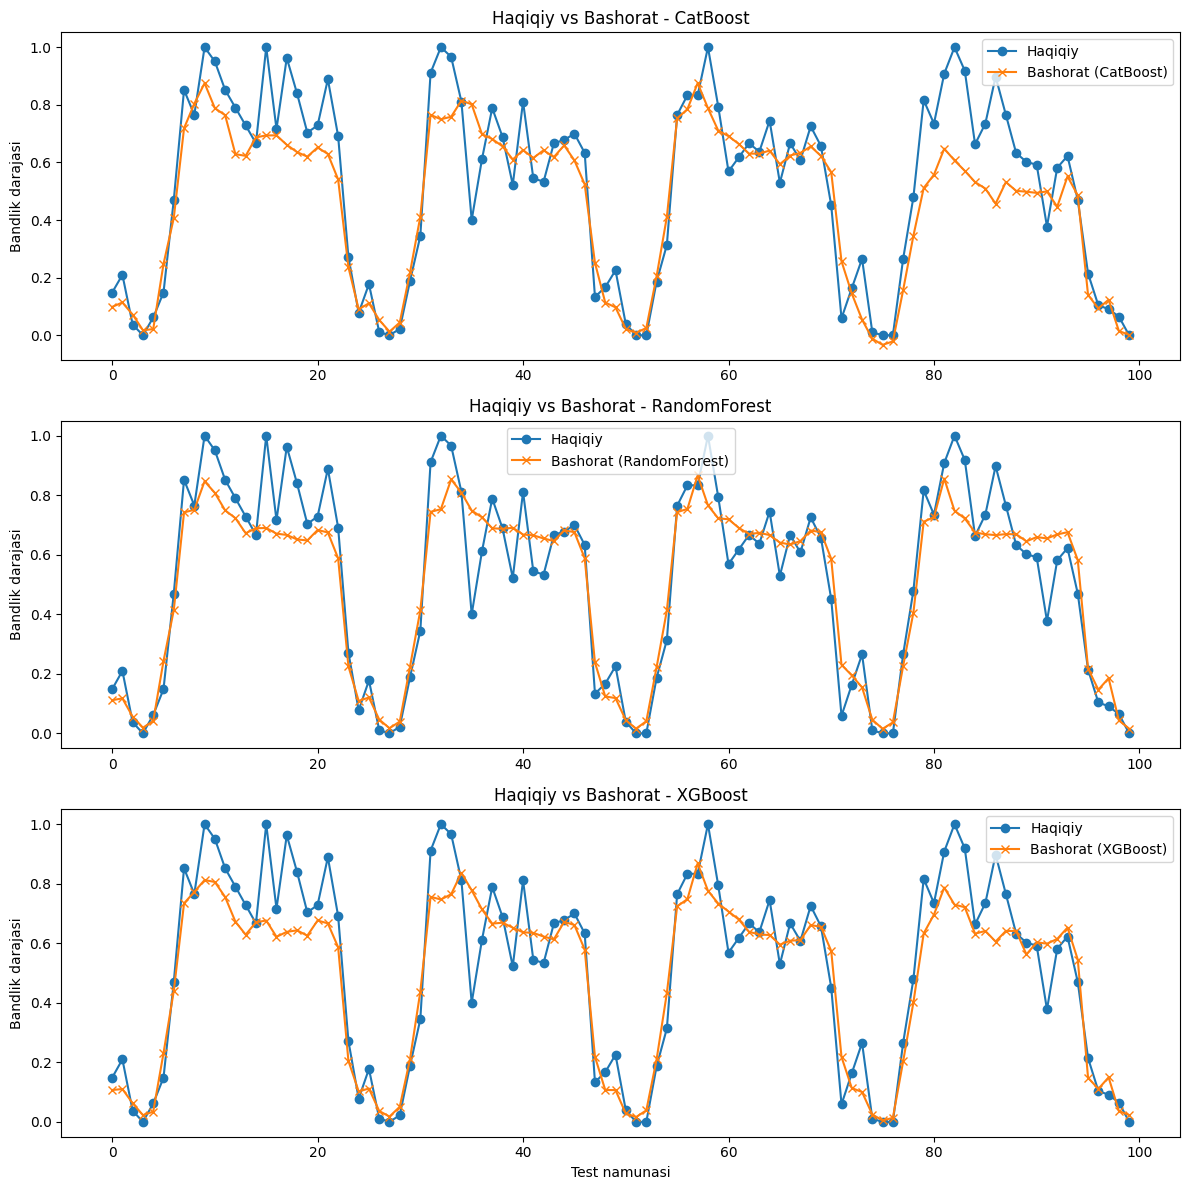

In [159]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

modellar = [('CatBoost', cat_preds_2), ('RandomForest', rf_preds_2), ('XGBoost', xgb_preds_2)]

for i, (name, preds) in enumerate(modellar):
    axes[i].plot(y2_test.values[:100], label='Haqiqiy', marker='o')
    axes[i].plot(preds[:100], label=f'Bashorat ({name})', marker='x')
    axes[i].legend()
    axes[i].set_title(f'Haqiqiy vs Bashorat - {name}')
    axes[i].set_ylabel('Bandlik darajasi')

axes[2].set_xlabel('Test namunasi')
plt.tight_layout()
plt.show()